In [1]:
import jax
import jax.numpy as jnp
import functions
import pybamm
import numpy as np

In [2]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")
# params_bat["Lower voltage cut-off [V]"] = -100.0
# params_bat["Upper voltage cut-off [V]"] = 100.0
# params_bat["Maximum concentration in negative electrode [mol.m-3]"] = 100e6
# params_bat["Maximum concentration in positive electrode [mol.m-3]"] = 100e6
# # params_bat["Minimum concentration in negative electrode [mol.m-3]"] = -100e6
# # params_bat["Minimum concentration in positive electrode [mol.m-3]"] = -100e6


# Hyperparameters
num_train = 2200
num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]

t_max = 3600
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [3]:
spm = pybamm.lithium_ion.SPM()
spm.events = []
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]

def get_targets(I_samples, socs=[0.5]):
    set_targets_anode = []
    set_targets_cathode = []
    set_c0_anode = []
    set_c0_cathode = []
    set_currents = []

    #I_pruned = []

    #fast_solver = pybamm.CasadiSolver(atol=1e-3, rtol=1e-3, mode="fast")
    
    for soc in socs:
        print(f"SOC: {soc}")
        for id, I_func in enumerate(I_samples):
            # Update parameter
            params_bat = pybamm.ParameterValues("Chen2020")
            params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* I_func, pybamm.t)
            # params_bat["Negative particle diffusivity [m2.s-1]"] = 3.3e-14
            # params_bat["Positive particle diffusivity [m2.s-1]"] = 4e-15

            # Re-create the simulation with updated parameters
            sim = pybamm.Simulation(spm, parameter_values=params_bat)#, solver=fast_solver)
            sol = sim.solve(initial_soc=soc, t_eval=t)

            c0_anode = sol["Negative particle concentration"].entries[:,0,0]
            cn_target_anode = sol["Negative particle concentration"].entries[:,0,:]
            
            c0_cathode = sol["Positive particle concentration"].entries[:,0,0]
            cn_target_cathode = sol["Positive particle concentration"].entries[:,0,:]

            # if cn_target.shape[-1] != num_samples_I:
            #     continue
            # else:
            #     I_pruned.append(I_func)

            #I_pruned.append(I_func)
            
            set_targets_anode.append(cn_target_anode)
            set_c0_anode.append(c0_anode)

            set_targets_cathode.append(cn_target_cathode)
            set_c0_cathode.append(c0_cathode)
            set_currents.append(I_func)

    
    return set_targets_anode, set_c0_anode, set_targets_cathode, set_c0_cathode, set_currents


def generate_data(key, num, family = "CC"):
    keys = jax.random.split(key, num)
    train_I = []

    if family == "GRF":
        for k in keys:
            # Generate a random current function
            I_func = functions.GaussianRFCurrent(k, C, t_max)
            train_I.append(I_func(t))

    if family == "Triangle":
        for k in keys:
            # Sample a random amplitude value for the triangle current
            value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
            I_func = functions.TriangleCurrent(value * C)
            train_I.append(I_func(t))

    if family == "CC":
        for k in keys:
            # Generate a random constant current value between -1C and 1C
            value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
            I_func = functions.ConstantCurrent(value*C)
            # Evaluate at times t and append
            train_I.append(I_func(t))

    return train_I


In [4]:
socs = [0.5]
families = ["CC","GRF","Triangle"]
# Dan, Dca = [1e-17,1e-16,1e-15,1e-14,1e-13,1e-12,1e-11,1e-10]

In [5]:
train_I = generate_data(key_train, num_train, family = families[0])
test_I = generate_data(key_test, num_test, family = families[0])
train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode, train_I = get_targets(train_I, socs = socs)
test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode, test_I = get_targets(test_I, socs = socs)

train_I = np.array(train_I)
test_I = np.array(test_I)

train_cn_anode = np.array(train_cn_anode)
test_cn_anode = np.array(test_cn_anode)
train_c0_anode = np.array(train_c0_anode)
test_c0_anode = np.array(test_c0_anode)

train_cn_cathode = np.array(train_cn_cathode)
test_cn_cathode = np.array(test_cn_cathode)
train_c0_cathode = np.array(train_c0_cathode)
test_c0_cathode = np.array(test_c0_cathode)

SOC: 0.5
SOC: 0.5


In [6]:
shapes = [i.shape for i in train_cn_anode]

In [7]:
len(shapes)

2200

In [8]:
filename = families[0]
path = "data/spm/DON/"
np.savez(path + "train/" + filename + ".npz", current=train_I, initial_concentration_anode=train_c0_anode, target_concentration_anode=train_cn_anode,
         initial_concentration_cathode=train_c0_cathode, target_concentration_cathode=train_cn_cathode, diffusivity_anode = 1, diffusivity_cathode = 1)
np.savez(path + "test/" + filename + ".npz", current=test_I, initial_concentration_anode=test_c0_anode, target_concentration_anode=test_cn_anode,
         initial_concentration_cathode=test_c0_cathode, target_concentration_cathode=test_cn_cathode, diffusivity_anode = 1, diffusivity_cathode = 1)

In [9]:
train_data = np.load(path + "train/" + filename + ".npz")
test_data = np.load(path + "test/" + filename + ".npz")

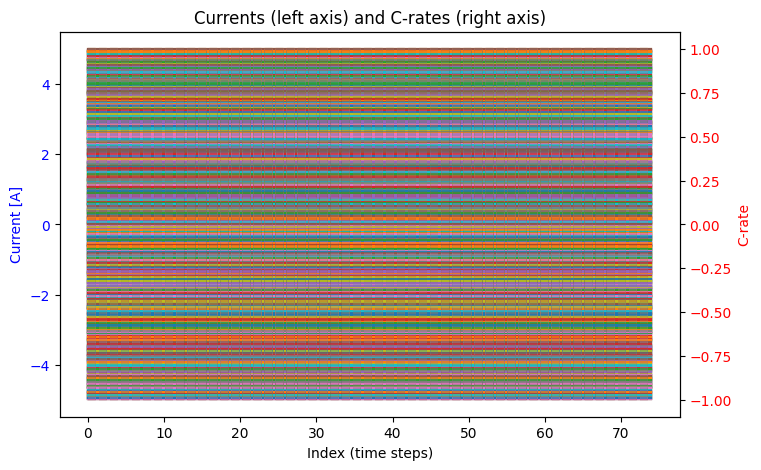

In [10]:
import matplotlib.pyplot as plt

# Suppose train_data["current"] is a numpy array of shape (14, 75),
# and we have some known battery capacity in ampere-hours, e.g. C = 5.0
data = train_data["current"]

# Create a figure with one Axes, then a twin Axes for second scale
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the currents on ax1
for i in range(data.shape[0]):
    ax1.plot(data[i, :], label=f"Series {i}")

ax1.set_xlabel("Index (time steps)")
ax1.set_ylabel("Current [A]", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Create second y‐axis for the C‐rate
ax2 = ax1.twinx()
for i in range(data.shape[0]):
    # Convert current [A] into C‐rate by dividing by capacity [Ah]
    # (If your capacity is in different units, adjust accordingly)
    c_rate = data[i, :] / C
    ax2.plot(c_rate, linestyle="--", alpha=0.7)

ax2.set_ylabel("C-rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Currents (left axis) and C-rates (right axis)")
plt.show()


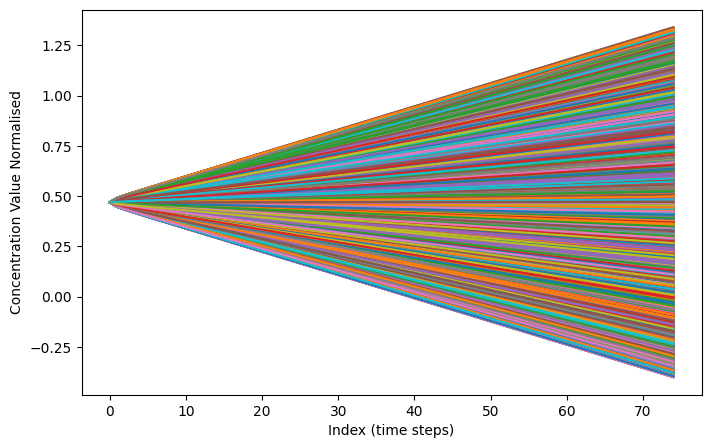

In [11]:
data = train_data["target_concentration_anode"]

plt.figure(figsize=(8, 5))

for i in range(data.shape[0]):  # i goes from 0 to 13
    plt.plot(data[i,-1, :], label=f"Series {i}")

plt.xlabel("Index (time steps)")
plt.ylabel("Concentration Value Normalised")
#plt.title("All 14 Current Traces in One Plot")
#plt.legend()
plt.show()

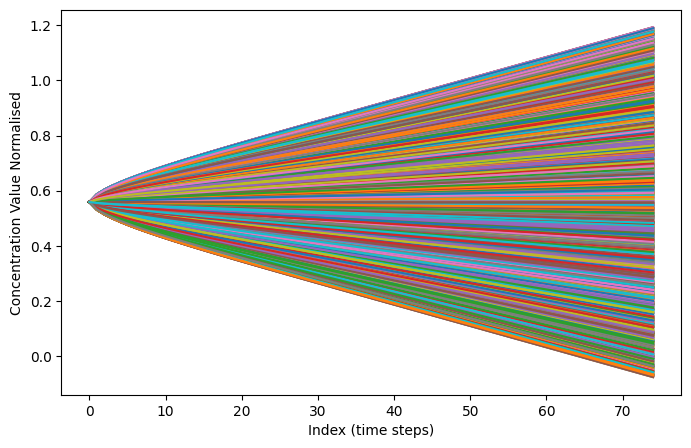

In [12]:
data = train_data["target_concentration_cathode"]

plt.figure(figsize=(8, 5))

for i in range(data.shape[0]):  # i goes from 0 to 13
    plt.plot(data[i,-1, :], label=f"Series {i}")

plt.xlabel("Index (time steps)")
plt.ylabel("Concentration Value Normalised")
#plt.title("All 14 Current Traces in One Plot")
#plt.legend()
plt.show()

In [13]:
train_data["current"].shape

(2200, 75)

In [14]:
train_I = generate_data(key_train, num_train, family = families[1])
test_I = generate_data(key_test, num_test, family = families[1])
train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode, train_I = get_targets(train_I, socs = socs)
test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode, test_I = get_targets(test_I, socs = socs)

train_I = np.array(train_I)
test_I = np.array(test_I)

train_cn_anode = np.array(train_cn_anode)
test_cn_anode = np.array(test_cn_anode)
train_c0_anode = np.array(train_c0_anode)
test_c0_anode = np.array(test_c0_anode)

train_cn_cathode = np.array(train_cn_cathode)
test_cn_cathode = np.array(test_cn_cathode)
train_c0_cathode = np.array(train_c0_cathode)
test_c0_cathode = np.array(test_c0_cathode)

filename = families[1]
path = "data/spm/DON/"
np.savez(path + "train/" + filename + ".npz", current=train_I, initial_concentration_anode=train_c0_anode, target_concentration_anode=train_cn_anode,
         initial_concentration_cathode=train_c0_cathode, target_concentration_cathode=train_cn_cathode, diffusivity_anode = 1, diffusivity_cathode = 1)
np.savez(path + "test/" + filename + ".npz", current=test_I, initial_concentration_anode=test_c0_anode, target_concentration_anode=test_cn_anode,
         initial_concentration_cathode=test_c0_cathode, target_concentration_cathode=test_cn_cathode, diffusivity_anode = 1, diffusivity_cathode = 1)

SOC: 0.5
SOC: 0.5


In [15]:
train_I = generate_data(key_train, num_train, family = families[2])
test_I = generate_data(key_test, num_test, family = families[2])
train_cn_anode, train_c0_anode, train_cn_cathode, train_c0_cathode, train_I = get_targets(train_I, socs = socs)
test_cn_anode, test_c0_anode, test_cn_cathode, test_c0_cathode, test_I = get_targets(test_I, socs = socs)

train_I = np.array(train_I)
test_I = np.array(test_I)

train_cn_anode = np.array(train_cn_anode)
test_cn_anode = np.array(test_cn_anode)
train_c0_anode = np.array(train_c0_anode)
test_c0_anode = np.array(test_c0_anode)

train_cn_cathode = np.array(train_cn_cathode)
test_cn_cathode = np.array(test_cn_cathode)
train_c0_cathode = np.array(train_c0_cathode)
test_c0_cathode = np.array(test_c0_cathode)

filename = families[2]
path = "data/spm/DON/"
np.savez(path + "train/" + filename + ".npz", current=train_I, initial_concentration_anode=train_c0_anode, target_concentration_anode=train_cn_anode,
         initial_concentration_cathode=train_c0_cathode, target_concentration_cathode=train_cn_cathode, diffusivity_anode = 1, diffusivity_cathode = 1)
np.savez(path + "test/" + filename + ".npz", current=test_I, initial_concentration_anode=test_c0_anode, target_concentration_anode=test_cn_anode,
         initial_concentration_cathode=test_c0_cathode, target_concentration_cathode=test_cn_cathode, diffusivity_anode = 1, diffusivity_cathode = 1)

SOC: 0.5


SOC: 0.5
